# <ins>**Exploring the rates of employment between males and females who are in receipt of long term support, primarily for learning disability support, during 2022.**</ins>

## <ins> Rationale </ins>

Data collected from the NHS Digital indicated that the proportion of males in England who received long term support with a primary support reason of learning disability (LD) support and were in paid employment was 5.2% (NHS Digital, 2023). For females the employment proportion was 4.0%. The Office for Health Improvement and Disparities (OHID), part of The Department of Health & Social Care, provided further data through their Fingertips|Public Health Profiles service (OHID,2026). In OHID's data, further analysis showed the proportions of males and females who received support primarily for a LD in paid work grouped by deprivation deciles using the English indices of deprivation.

The analysis conducted by the government departments presented descriptive proportions as well as confidence intervals calculated using the Wilson Score method. While the Wilson Score method is useful for providing a range for imprecision, other methods are more appropriate for testing independent associations across multiple predictors. An alternative option for analysing the data is a binary logistic regression, which may be used to calculate probability estimates from log odds.

#### Research Question

What are the effects of both sex and deprivation decile on employment likelihood for adults receiving long term support for a learning disability?

#### Hypotheses

H $_1$ : There is a significant effect of sex on the probability that an adult with a learning disability on long term support would be in work.

H $_2$ : There is a significant effect of deprivation decile on the probability that an adult with a learning disability on long term support would be in work.

#### Null Hypotheses

H $_{01}$: There is no significant effect of sex on the probability that an adult with a learning disability on long term support would be in work.

H $_{02}$: There is no significant effect of deprivation decile on the probability that an adult with a learning disability on long term support would be in work.

## <ins> Data Collection </ins>

In [126]:
# Imports relevant libraries.
import psycopg2 as psy2
import fingertips_py as ftp
import numpy as np
import pandas as pd
from sqlalchemy import create_engine
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

In [127]:
pd.options.display.float_format = "{:,.2f}".format

In [ ]:
# Retrieves data from Fingertips Public Health Profiles.
# Note: Area Type 6 for statistical regions, 15 for England.
data = ftp.retrieve_data.get_data_by_indicator_ids([93884], area_type_id=15, include_sortable_time_periods=True)

In [ ]:
data.head(1)

,Indicator ID,Indicator Name,Parent Code,Parent Name,Area Code,Area Name,Area Type,Sex,Age,Category Type,...,Count,Denominator,Value note,Recent Trend,Compared to England value or percentiles,Compared to percentiles,Time period Sortable,New data,Compared to goal,Time period range
0,93884,The percentage of the population who are in re...,NaN,NaN,E92000001,England,England,Male,18-64 yrs,NaN,...,"4,747.00","76,827.00",NaN,NaN,Not compared,Not compared,20160000,NaN,NaN,1y


As seen in the data, the year column will need formatted. The year will need to be divided by 10,000 to isolate the year. The Count and Denominator columns will need to be casted as ints too. Although firstly, null values from Count and Denominator will need dropped. The data will also be filtered for the year 2022. Category Type null values will be filtered so only deprivation deciles remain. 

In [ ]:
# Lower cases column names and replaces spaces.

data = data.rename(columns = lambda x: x.replace(" ","_").lower())

In [131]:
# Null values dropped first.

data_ld = data[(data["denominator"].notnull())
                     &(data["count"].notnull())
                      &(data["time_period_sortable"] == 20220000)
                      &(data["sex"] != "Persons")
                      &(data["category_type"].notnull())
                       ].copy().reset_index(drop=True)

In [132]:
# Column values -> ints
data_ld.time_period_sortable = data_ld.time_period_sortable.apply(lambda x: int(x/10000))
data_ld.denominator = data_ld.denominator.apply(lambda x: int(x))
data_ld["count"] = data_ld["count"].apply(lambda x: int(x))

In [133]:
data_ld.head(1)

,indicator_id,indicator_name,parent_code,parent_name,area_code,area_name,area_type,sex,age,category_type,...,count,denominator,value_note,recent_trend,compared_to_england_value_or_percentiles,compared_to_percentiles,time_period_sortable,new_data,compared_to_goal,time_period_range
0,93884,The percentage of the population who are in re...,NaN,NaN,E92000001,England,England,Male,18-64 yrs,County & UA deprivation deciles in England (IM...,...,223,7739,NaN,Cannot be calculated,Worse,Not compared,2022,NaN,NaN,1y


The values are now formatted correctly. Before dropping columns, the Value note column will be checked for data quality issues.

In [134]:
# Check value notes for quality issue notes.
for x in data_ld.value_note.unique():
    print(x)

nan
Value excludes contribution from areas with suppressed values 


There are some supressed values, however the impact on the binary regression is expected to be limited. Next duplicate entries will be checked for and removed.

In [135]:
duplicated = data_ld.duplicated(subset=["count","denominator","sex","category_type"], keep=False)
if True in duplicated.values:
    print("Duplicates found")

Duplicates found


In [136]:
data_dd = data_ld.drop_duplicates(subset=["count","denominator","sex","category_type"],keep="last").copy().reset_index(drop=True)

Now that duplicates have been removed, a column will be needed for the total not in paid employment. As the denominator in the data is adults aged 16-64 receiving long term support for primarily a learning disability, and count represents people in that group paid employment:

 $ N_{not\ in\ paid\ employment} = Total - N_{in\ paid\ employment} $

In [137]:
data_dd["not_paid_employment"] = data_dd.denominator - data_dd["count"]

Only columns needed for analysis are kept.

In [138]:
# Keeps relevant columns

data_red = data_dd[["sex","category","count","not_paid_employment"]].copy()
data_red = data_red.rename(columns={"count":"paid_employment"})

Next for deprivation deciles (category column), each decile will be recoded to an integer scoring where 1 = most deprived decile and 10 = least. Although this is just for visualisation, deciles will be passed as categories when modelling the results. This remains in line with the English indices of depravation (2025) statistical release, that the indices itself cannot be used for quantifying how deprived each of the areas are (Ministry of Housing, Communities, and Local Government, 2025).

In [139]:
change_dict = {
    "Most deprived decile (IMD2019)": 10,
    "Second most deprived decile (IMD2019)": 9,
    "Third more deprived decile (IMD2019)": 8,
    "Fourth more deprived decile (IMD2019)": 7,
    "Fifth more deprived decile (IMD2019)": 6,
    "Fifth less deprived decile (IMD2019)": 5,
    "Fourth less deprived decile (IMD2019)": 4,
    "Third less deprived decile (IMD2019)": 3,
    "Second least deprived decile (IMD2019)": 2,
    "Least deprived decile (IMD2019)": 1
 }

try:
    data_red.category = data_red.category.apply(lambda x: change_dict[x])
except Exception as e:
    print(f"cannot change: {e}")

## <ins> Visualisation </ins>

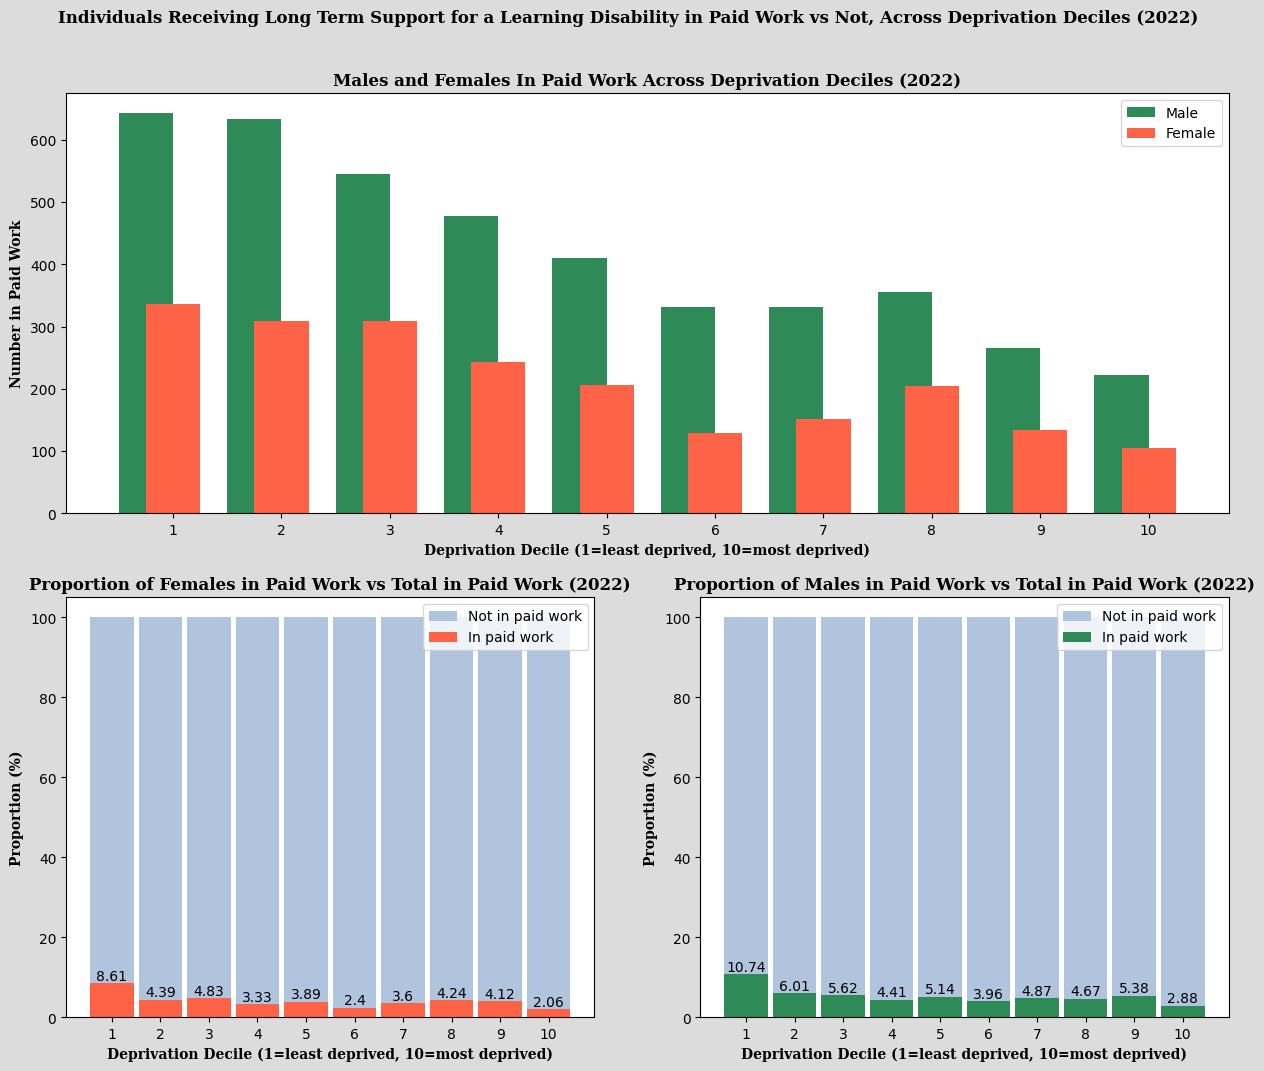

In [140]:
fig = plt.figure(figsize=(15,12),facecolor="gainsboro")
ax1 = fig.add_subplot(2,2,(1,2))
ax2 = fig.add_subplot(223)
ax3 = fig.add_subplot(224)

font_dict = {
    "fontweight":"bold",
    "family":"serif"
}

# Axes 1 plot
t1 = data_red[data_red.sex=="Male"].copy()
t2 = data_red[data_red.sex=="Female"].copy()

ax1.bar(t1.category-0.25,t1.paid_employment,label="Male",color="seagreen",width=0.5)
ax1.bar(t2.category,t2.paid_employment,label="Female",color="tomato",width=0.5)

ax1.set_xlabel("Deprivation Decile (1=least deprived, 10=most deprived)",fontdict=font_dict)
ax1.set_xticks(t1.category)
ax1.set_ylabel("Number in Paid Work",fontdict=font_dict)
ax1.set_title("Males and Females In Paid Work Across Deprivation Deciles (2022)",fontdict=font_dict)

ax1.legend()

# Axes 2 plot
proportion_f = np.round(((t2.paid_employment)/
                       (t2.not_paid_employment.values+t2.paid_employment.values))*100,2)

a=ax2.bar(t2.category,100,label="Not in paid work",color="lightsteelblue",width=0.9)
b=ax2.bar(t1.category,proportion_f,label="In paid work",color="tomato",width=0.9)
ax2.bar_label(b)

ax2.set_xlabel("Deprivation Decile (1=least deprived, 10=most deprived)",fontdict=font_dict)
ax2.set_xticks(t1.category)
ax2.set_ylabel("Proportion (%)",fontdict=font_dict)
ax2.set_title('Proportion of Females in Paid Work vs Total in Paid Work (2022)',fontdict=font_dict)

ax2.legend()

# Axes 3 plot
proportion_m = np.round(((t1.paid_employment)/
                       (t1.not_paid_employment.values+t1.paid_employment.values))*100,2)

a=ax3.bar(t1.category,100,label="Not in paid work",color="lightsteelblue",width=0.9)
b=ax3.bar(t1.category,proportion_m,label="In paid work",color="seagreen",width=0.9)
ax3.bar_label(b)

ax3.set_xlabel("Deprivation Decile (1=least deprived, 10=most deprived)",fontdict=font_dict)
ax3.set_xticks(t1.category)
ax3.set_ylabel("Proportion (%)",fontdict=font_dict)
ax3.set_title('Proportion of Males in Paid Work vs Total in Paid Work (2022)',fontdict=font_dict)

ax3.legend()

fig.suptitle("Individuals Receiving Long Term Support for a Learning Disability in Paid Work vs Not, Across Deprivation Deciles (2022)",
             fontdict=font_dict,fontweight="bold",y=0.95)
plt.style.use("fast")
plt.show()

As seen in the bar charts, men have higher employment rates compared to women across all deprivation deciles. Furthermore, when looking at the proportion of each sex group in work vs not relative to the total number of people recorded in that group, males consistently still have higher rates of employment across all deciles.



## <ins> Logistic Binomial Regression Model </ins>

The data was dissagregated into individual Bernoulli trials. 

In [141]:
ones = pd.DataFrame({"sex":data_red["sex"].repeat(data_red["paid_employment"]),
                     "deprivation_decile":data_red["category"].repeat(data_red["paid_employment"]),
                     "in_work": 1})

zeroes = pd.DataFrame({"sex":data_red["sex"].repeat(data_red["not_paid_employment"]),
                       "deprivation_decile":data_red["category"].repeat(data_red["not_paid_employment"]),
                       "in_work": 0})

binary_df = pd.concat([ones,zeroes])
binary_df = binary_df.reset_index(drop=True)


### <ins>Model</ins>

In [142]:
model = smf.logit(formula="in_work ~ C(sex) + C(deprivation_decile)",data=binary_df)
result = model.fit()
result.summary()

Optimization terminated successfully.
         Current function value: 0.188328
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                in_work   No. Observations:               133182
Model:                          Logit   Df Residuals:                   133171
Method:                           MLE   Df Model:                           10
Date:                Wed, 11 Mar 2026   Pseudo R-squ.:                 0.01639
Time:                        11:31:57   Log-Likelihood:                -25082.
converged:                       True   LL-Null:                       -25500.
Covariance Type:            nonrobust   LLR p-value:                3.784e-173
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -2.3823      0.038    -62.412      0.000      -2.457      -2.307
C(sex)[T.Male]                  0.2750      0.027     10.077      0.000       0.221       0.328
C(deprivation_decile)[T.2]     -0.6619      0.048    -13.933      0.000      -0.755      -0.569
C(deprivation_decile)[T.3]     -0.6732      0.049    -13.819      0.000      -0.769      -0.578
C(deprivation_decile)[T.4]     -0.9746      0.051    -19.185      0.000      -1.074      -0.875
C(deprivation_decile)[T.5]     -0.8132      0.053    -15.263      0.000      -0.918      -0.709
C(deprivation_decile)[T.6]     -1.1556      0.058    -19.874      0.000      -1.270      -1.042
C(deprivation_decile)[T.7]     -0.8785      0.058    -15.276      0.000      -0.991      -0.766
C(deprivation_decile)[T.8]     -0.8480      0.055    -15.464      0.000      -0.955      -0.740
C(deprivation_decile)[T.9]     -0.7611      0.061    -12.391      0.000      -0.881      -0.641
C(deprivation_decile)[T.10]    -1.4328      0.065    -21.939      0.000      -1.561      -1.305
===============================================================================================
"""

In [152]:
# Prints chi-squared value

print(result.llr)

835.9798087783929


A binary logistic regression analysis was conducted to explore the effects of both sex, and deprivation decile on the likelihood that a working age individual (16-64) on long term support primarily for a learning disability, is in paid employment during 2022. The results showed that the model was significant compared to the null model (χ<sup>2</sup>(10) = 835.980, p < 0.001), significantly indicating an effect of the categorical predictors. While the variance explained is low (McFadden's pseudo-R<sup>2</sup> = 0.02), this is typical for healthcare data due to the large number of varibles that could have an effect on someones ability to be in paid work. 

### <ins>Odds Ratios and Probabilities</ins>

To rejoin the data onto the original table, the parameters will need renamed for the join.

In [144]:
baseline_odds = np.exp(result.params.iloc[0])

results_frame = pd.DataFrame(result.params,columns=["beta_coefficients"]).reset_index().rename(columns={"index":"sex"})

before_string = "T."
after_string = "]"

results_frame.sex = results_frame.sex.apply(lambda x: x[x.find(before_string)+2:-1] if x != "Intercept" else "Female")

# Add category column
results_frame["category"] = results_frame.sex.apply(lambda x: x if x not in ["Female","Male"] else 1)

# Changes numbers in sex column to Female.
results_frame.sex = results_frame.sex.apply(lambda x: "Female" if x != "Male" else x)

# Reorders columns
results_frame = results_frame[["sex","category","beta_coefficients"]]

In [145]:
# Creates table for male beta coefficients across deprivations deciles, both male and area coefficients are added.

male_frame = results_frame.iloc[1:].copy()

male_frame.sex = male_frame.sex.apply(lambda x: "Male")
male_frame.loc[2:,"beta_coefficients"] = male_frame.loc[1:,"beta_coefficients"] + male_frame.beta_coefficients.iloc[0]
male_frame.head(3)

,sex,category,beta_coefficients
1,Male,1,0.27
2,Male,2,-0.39
3,Male,3,-0.40


In [146]:
final_frame = pd.concat([results_frame,male_frame])
final_frame = final_frame.drop_duplicates(subset=["sex","category"],keep="last").reset_index(drop=True)

In [147]:
final_frame.iloc[[1,10,12]]

,sex,category,beta_coefficients
1,Female,2,-0.66
10,Male,1,0.27
12,Male,3,-0.40


Now odds ratios (OR) can be calculated for each of the predictors coefficients. The baseline females in the least deprived deciles is simply 1.

Letting x be any variable other than the reference (β0):

$ OR \mathit{_{x} = \frac{e^{β0}\ \cdot\ e^{βx}}{e^{β0}} = {e^{βx}}}$

For the odds, these are calculated for the non-reference variables:

$ Odds \mathit{_{x} = e^{βx}\ \cdot\ e^{β0} =\ e^{β0\ +\ βx}}$

or the following for the reference variable:

$ Odds \mathit{_{x\ =0} = e^{β0}}$

Then probabilities are calculated with:

$ P \mathit{_{x} = \frac{Odds_{x}}{1\ +\ Odds_{x}}}$

In [148]:
# Gets odds ratios from beta coefficients.
final_frame["odds_ratio"] = np.exp(final_frame.beta_coefficients)
final_frame.loc[0,"odds_ratio"] = 1

# Converts odds ratios into actual odds.
final_frame["actual_odds"] = np.exp(final_frame.beta_coefficients[0]) * final_frame.odds_ratio[1:] 
final_frame.loc[0,"actual_odds"] = np.exp(final_frame.beta_coefficients[0])

# Calculates and adds probabilities column.
final_frame["probability"] = (final_frame.actual_odds/(1+final_frame.actual_odds))

# Calculates and adds x in 20 column.
final_frame["prob_%"] = final_frame.probability * 100
final_frame["prob_fract"] = final_frame.probability.apply(lambda x: "1 in " + str(round(1/x,2)))
final_frame["prob_fract_rounded"] = final_frame.probability.apply(lambda x: "1 in " + str(5*round((1/x)/5)))

In [149]:
final_frame.sort_values(by="prob_%",ascending=False)

,sex,category,beta_coefficients,odds_ratio,actual_odds,probability,prob_%,prob_fract,prob_fract_rounded
10,Male,1,0.27,1.32,0.12,0.11,10.84,1 in 9.23,1 in 10
0,Female,1,-2.38,1.00,0.09,0.08,8.45,1 in 11.83,1 in 10
11,Male,2,-0.39,0.68,0.06,0.06,5.90,1 in 16.95,1 in 15
12,Male,3,-0.40,0.67,0.06,0.06,5.84,1 in 17.13,1 in 15
18,Male,9,-0.49,0.62,0.06,0.05,5.37,1 in 18.61,1 in 20
14,Male,5,-0.54,0.58,0.05,0.05,5.11,1 in 19.55,1 in 20
17,Male,8,-0.57,0.56,0.05,0.05,4.95,1 in 20.21,1 in 20
16,Male,7,-0.60,0.55,0.05,0.05,4.81,1 in 20.8,1 in 20
1,Female,2,-0.66,0.52,0.05,0.05,4.55,1 in 21.99,1 in 20
2,Female,3,-0.67,0.51,0.05,0.04,4.50,1 in 22.23,1 in 20


## <ins> Discussion </ins>

### Effect: Sex

The results indicated a large gap in paid employment between males and females in the least deprived decile with an absolute difference of ~2.39%. This trend of males having higher employment probabilities can be observed across all of the deciles. For example, there was an absolute difference of ~0.66% between the sexes in the most deprived decile.

Furthermore, the probabilities of employment for males in the 2<sup>nd</sup> least, 3<sup>rd</sup> least, 5<sup>th</sup> least, 2<sup>nd</sup> most, 3<sup>rd</sup> most, and 4<sup>th</sup> most deprived deciles were all higher than females in the second least deprived decile.

### Effect: Deprivation

There was an absolute difference of 8.02% in the probabilities between males in the least and most deprived deciles, and for females, this difference was 6.29%.

However as mentioned within the English Indices of Deprivation (2025), the deprivation index cannot be used for quantifying deprivation. As such, the current analysis cannot indicate why amongst both males and females the second most deprived decile had the 4<sup>th</sup> highest probability for paid employment.

### Conclusions

It is important to consider the intersections between sex and deprivation. For example, if the employment rate for females was to match males in the least deprived deciles, then from a broad perspective, the amount of females in paid work overall would rise. This however, would undermine that female employment opportunities would still remain below males' in the most deprived deciles.

While the official report indicated that the differences in proportion between males and females overall in England was ~1.2% (NHS Digital, 2023), this figure arguably did not fully represent the disparity between males and females when controlling for deprivation.

Further studies could potentially look at other factors that may impact on whether adults with a LD are in paid work. Examples include type of support, the frequency of support provided, external support such as that provided by family and friends, and type of learning disability. Additionally, there may be other intersections that could impact on the disparity in paid employment such as ethnicity, age, and sexuality (NHS England, n.d.).

## <ins> Probabilities Bar Chart (2022) </ins>

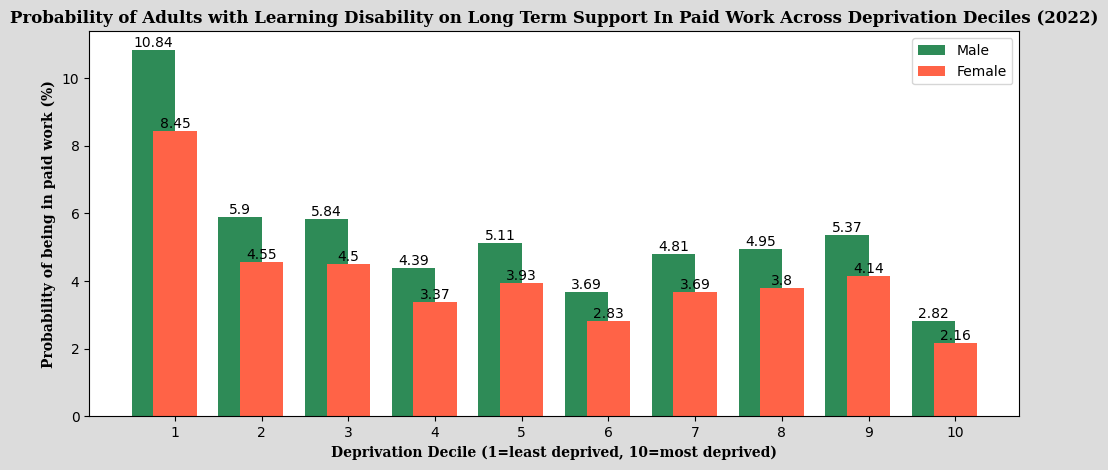

In [150]:
fig, ax = plt.subplots(figsize=(12,5),facecolor="gainsboro")

font_dict = {
    "fontweight":"bold",
    "family":"serif"
}

# Probability bars
f1 = final_frame[final_frame.sex=="Male"].copy()
f2 = final_frame[final_frame.sex=="Female"].copy()

m_prob = ax.bar(f1.category.astype(int)-0.25,round(f1["prob_%"],2),label="Male",color="seagreen",width=0.5)
f_prob = ax.bar(f2.category.astype(int),round(f2["prob_%"],2),label="Female",color="tomato",width=0.5)

ax.set_xlabel("Deprivation Decile (1=least deprived, 10=most deprived)",fontdict=font_dict)
ax.set_xticks(f1.category.astype(int))
ax.set_ylabel("Probability of being in paid work (%)",fontdict=font_dict)
ax.set_title("Probability of Adults with Learning Disability on Long Term Support In Paid Work Across Deprivation Deciles (2022)",fontdict=font_dict)
ax.bar_label(m_prob)
ax.bar_label(f_prob)

ax.legend()

## <ins>Copyright</ins>

**Data Source:**

Office for Health Improvement & Disparities. Public Health Profiles. 2026. https://fingertips.phe.org.uk © Crown copyright 2026.

**English Indices of Deprivation (2025):**

Ministry of Housing, Communities and Local Government. English indices of deprivation 2025. https://www.gov.uk/government/statistics/english-indices-of-deprivation-2025

**Report Source:**

NHS Digital. Measures from the Adult Social Care Outcomes Framework 2022. 2023. https://digital.nhs.uk/data-and-information/publications/statistical/adult-social-care-outcomes-framework-ascof 

Contains public sector information licensed under the Open Government Licence v3.0.

**Other References:**

NHS England. Ethnicity health. N.D. https://www.england.nhs.uk/about/equality/equality-hub/national-healthcare-inequalities-improvement-programme/what-are-healthcare-inequalities/ethnicity-health/
